# 04 — RAG System Evaluation

**Goal:** Evaluate the RAG pipeline on a 20-question test set across three dimensions:
- **Faithfulness** — is the answer supported by retrieved chunks?
- **Answer Relevancy** — does the answer address the question?
- **Retrieval Precision** — are the 4 retrieved chunks relevant?

Also benchmarks chunk sizes 300 vs 500 vs 800 words.

**Output:** `reports/evaluation_results.md`

**API cost:** ~$0.10 USD (20 questions + chunk comparison)

## 1. Load Test Set (20 Questions with Expected Answers)

In [1]:
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.vectorstore import load_vectorstore
from src.rag_chain import FinancialRAGChain
from src.document_processor import load_chunks, chunk_documents
from src.vectorstore import create_vectorstore

VECTORSTORE_DIR = str(ROOT / 'vectorstore')
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

# 20 test questions with expected answer keywords (manually verified)
# Each dict: question, expected_keywords (list), bank_context
TEST_SET = [
    # --- Financial metrics (5) ---
    {'id': 1,  'category': 'Metrics', 'bank': 'JPMorgan Chase',  'question': "What was JPMorgan's total net revenue in 2023?",         'keywords': ['revenue', 'billion']},
    {'id': 2,  'category': 'Metrics', 'bank': 'Bank of America', 'question': "What was Bank of America's net income in 2023?",          'keywords': ['income', 'billion']},
    {'id': 3,  'category': 'Metrics', 'bank': 'Wells Fargo',     'question': "What was Wells Fargo's return on equity in 2023?",        'keywords': ['return', 'equity', '%']},
    {'id': 4,  'category': 'Metrics', 'bank': 'JPMorgan Chase',  'question': "What is JPMorgan's CET1 capital ratio?",                  'keywords': ['capital', 'ratio', '%']},
    {'id': 5,  'category': 'Metrics', 'bank': 'Bank of America', 'question': "What was Bank of America's provision for credit losses?", 'keywords': ['provision', 'credit', 'billion']},
    # --- Risk factors (5) ---
    {'id': 6,  'category': 'Risk',    'bank': 'JPMorgan Chase',  'question': "What are JPMorgan's main risk categories in 2023?",       'keywords': ['risk', 'credit', 'market', 'operational']},
    {'id': 7,  'category': 'Risk',    'bank': 'Wells Fargo',     'question': "How does Wells Fargo describe interest rate risk?",       'keywords': ['interest rate', 'risk', 'income']},
    {'id': 8,  'category': 'Risk',    'bank': 'Bank of America', 'question': "What regulatory risks does Bank of America face?",        'keywords': ['regulatory', 'compliance', 'capital']},
    {'id': 9,  'category': 'Risk',    'bank': 'JPMorgan Chase',  'question': "What is JPMorgan's exposure to commercial real estate?",  'keywords': ['commercial', 'real estate', 'exposure']},
    {'id': 10, 'category': 'Risk',    'bank': 'Wells Fargo',     'question': "What cyber and technology risks does Wells Fargo mention?",'keywords': ['cyber', 'technology', 'risk']},
    # --- Comparative (5) ---
    {'id': 11, 'category': 'Compare', 'bank': 'All',             'question': "Compare the CET1 capital ratios of the three banks",      'keywords': ['JPMorgan', 'Bank of America', 'Wells Fargo', '%']},
    {'id': 12, 'category': 'Compare', 'bank': 'All',             'question': "Which bank had the highest net interest income?",         'keywords': ['net interest income', 'billion']},
    {'id': 13, 'category': 'Compare', 'bank': 'All',             'question': "How do the three banks approach digital transformation?", 'keywords': ['digital', 'technology']},
    {'id': 14, 'category': 'Compare', 'bank': 'All',             'question': "Compare employee headcount across the three banks",       'keywords': ['employees', 'thousand']},
    {'id': 15, 'category': 'Compare', 'bank': 'All',             'question': "Compare risk management frameworks of JPMorgan and BofA", 'keywords': ['risk', 'framework', 'management']},
    # --- Conversational (3) ---
    {'id': 16, 'category': 'Conv',    'bank': 'JPMorgan Chase',  'question': "What were JPMorgan's main revenue drivers in 2023?",      'keywords': ['revenue', 'consumer', 'commercial']},
    {'id': 17, 'category': 'Conv',    'bank': 'JPMorgan Chase',  'question': "How did interest rate changes affect those revenues?",     'keywords': ['interest', 'rate', 'impact']},
    {'id': 18, 'category': 'Conv',    'bank': 'Bank of America', 'question': "And what about Bank of America's experience with rates?",  'keywords': ['Bank of America', 'interest', 'rate']},
    # --- Out of scope (2) ---
    {'id': 19, 'category': 'OOS',     'bank': 'None',            'question': "What is JPMorgan's current stock price?",                 'keywords': ["don't have", "not in", "cannot"]},
    {'id': 20, 'category': 'OOS',     'bank': 'None',            'question': "Who will lead Wells Fargo in 2030?",                      'keywords': ["don't have", "not in", "cannot"]},
]

print(f'Test set: {len(TEST_SET)} questions')
pd.DataFrame(TEST_SET)[['id','category','bank','question']].set_index('id')

Test set: 20 questions


,category,bank,question
id,,,
1,Metrics,JPMorgan Chase,What was JPMorgan's total net revenue in 2023?
2,Metrics,Bank of America,What was Bank of America's net income in 2023?
3,Metrics,Wells Fargo,What was Wells Fargo's return on equity in 2023?
4,Metrics,JPMorgan Chase,What is JPMorgan's CET1 capital ratio?
5,Metrics,Bank of America,What was Bank of America's provision for credi...
6,Risk,JPMorgan Chase,What are JPMorgan's main risk categories in 2023?
7,Risk,Wells Fargo,How does Wells Fargo describe interest rate risk?
8,Risk,Bank of America,What regulatory risks does Bank of America face?
9,Risk,JPMorgan Chase,What is JPMorgan's exposure to commercial real...


## 2. Run All 20 Questions

In [2]:
vs = load_vectorstore(VECTORSTORE_DIR)

results = []
chain = FinancialRAGChain(vs)

# Reset memory before conversational block (questions 16-18)
CONV_START = 16

for item in TEST_SET:
    if item['id'] == CONV_START:
        chain.clear_memory()  # fresh context for conversational test
    elif item['id'] not in range(CONV_START, CONV_START + 3):
        chain.clear_memory()  # each standalone question gets a fresh context

    t0 = time.time()
    result = chain.ask(item['question'])
    elapsed = time.time() - t0

    results.append({
        **item,
        'answer': result['answer'],
        'sources': result['sources'],
        'tokens': result['tokens_used'],
        'latency': round(elapsed, 2),
    })
    print(f"[{item['id']:02d}] {item['category']:7s} | {elapsed:.1f}s | Q: {item['question'][:60]}")

print(f'\nAll {len(results)} questions answered ✅')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Loaded vectorstore — 1183 documents from /Users/nicolaszuleta95/code_nz/financial-rag-assistant/vectorstore/


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[01] Metrics | 1.8s | Q: What was JPMorgan's total net revenue in 2023?
[02] Metrics | 1.5s | Q: What was Bank of America's net income in 2023?
[03] Metrics | 1.0s | Q: What was Wells Fargo's return on equity in 2023?
[04] Metrics | 2.5s | Q: What is JPMorgan's CET1 capital ratio?
[05] Metrics | 1.5s | Q: What was Bank of America's provision for credit losses?
[06] Risk    | 3.8s | Q: What are JPMorgan's main risk categories in 2023?
[07] Risk    | 3.8s | Q: How does Wells Fargo describe interest rate risk?
[08] Risk    | 6.9s | Q: What regulatory risks does Bank of America face?
[09] Risk    | 4.7s | Q: What is JPMorgan's exposure to commercial real estate?
[10] Risk    | 4.0s | Q: What cyber and technology risks does Wells Fargo mention?
[11] Compare | 3.6s | Q: Compare the CET1 capital ratios of the three banks
[12] Compare | 3.7s | Q: Which bank had the highest net interest income?
[13] Compare | 8.3s | Q: How do the three banks approach digital transformation?
[14] Compare | 6.6s 

## 3. Faithfulness Score

**Definition:** Proportion of answers where at least one expected keyword appears in the answer text (proxy for factual grounding).

For production, this would use a second LLM call to verify each fact; here we use keyword matching as a deterministic, zero-cost proxy.

In [3]:
def faithfulness_score(answer: str, keywords: list[str]) -> float:
    """1.0 if any keyword found in answer (case-insensitive), else 0.0."""
    answer_lower = answer.lower()
    return 1.0 if any(kw.lower() in answer_lower for kw in keywords) else 0.0

for r in results:
    r['faithfulness'] = faithfulness_score(r['answer'], r['keywords'])

df = pd.DataFrame(results)

overall_faith = df['faithfulness'].mean()
by_cat = df.groupby('category')['faithfulness'].mean()

print(f'Overall Faithfulness : {overall_faith:.1%}')
print('\nBy category:')
print(by_cat.round(3).to_string())

Overall Faithfulness : 90.0%

By category:
category
Compare    0.8
Conv       1.0
Metrics    0.8
OOS        1.0
Risk       1.0


## 4. Answer Relevancy Score

**Definition:** Does the answer address the question?
- 1.0 — directly answers the question
- 0.5 — partially answers
- 0.0 — does not answer

Here scored heuristically: out-of-scope questions with proper refusal score 1.0; answers longer than 50 words that contain at least one keyword score 1.0; others score 0.5.

In [4]:
def relevancy_score(answer: str, keywords: list[str], category: str) -> float:
    answer_lower = answer.lower()
    has_keywords = any(kw.lower() in answer_lower for kw in keywords)
    is_long = len(answer.split()) > 50

    if category == 'OOS':
        # Correct refusal
        return 1.0 if has_keywords else 0.0
    return 1.0 if (has_keywords and is_long) else 0.5

for r in results:
    r['relevancy'] = relevancy_score(r['answer'], r['keywords'], r['category'])

df = pd.DataFrame(results)
overall_rel = df['relevancy'].mean()
by_cat_rel = df.groupby('category')['relevancy'].mean()

print(f'Overall Answer Relevancy : {overall_rel:.1%}')
print('\nBy category:')
print(by_cat_rel.round(3).to_string())

Overall Answer Relevancy : 85.0%

By category:
category
Compare    0.8
Conv       1.0
Metrics    0.6
OOS        1.0
Risk       1.0


## 5. Retrieval Precision

**Definition:** Of the 4 chunks retrieved per question, what proportion are genuinely useful (i.e. their bank metadata matches the question's target bank)?

In [5]:
def retrieval_precision(sources: list[dict], target_bank: str) -> float:
    if target_bank == 'All' or target_bank == 'None' or not sources:
        return 1.0  # no specific bank expected
    relevant = sum(1 for s in sources if s['bank'] == target_bank)
    return relevant / len(sources)

for r in results:
    r['precision'] = retrieval_precision(r['sources'], r['bank'])

df = pd.DataFrame(results)
overall_prec = df['precision'].mean()
print(f'Overall Retrieval Precision : {overall_prec:.1%}')

Overall Retrieval Precision : 91.2%


## 6. Chunk Size Comparison — 300 vs 500 vs 800 words

Repeats the first 5 questions with different chunk sizes to measure impact on faithfulness and latency.

**⚠️ This creates two temporary vector stores — additional API cost ~$0.06 USD.**

In [6]:
CHUNKS_PATH = ROOT / 'data' / 'processed' / 'chunks_processed.json'
# We load original pages and re-chunk at different sizes
# Note: load_chunks returns already-split chunks; for re-chunking we need page data.
# Here we use the 5 metric questions as a lightweight proxy.

benchmark_questions = [r for r in results if r['category'] == 'Metrics']

# Re-use the default 500-word vectorstore for the baseline
chunk_sizes = [500]  # extend to [300, 500, 800] if you want to embed extra stores

chunk_results = {}
for cs in chunk_sizes:
    faithfulness_scores = []
    latencies = []
    # Use existing vs for 500; would need separate vs for other sizes
    test_chain = FinancialRAGChain(vs)
    for item in benchmark_questions:
        test_chain.clear_memory()
        t0 = time.time()
        res = test_chain.ask(item['question'])
        latencies.append(time.time() - t0)
        faithfulness_scores.append(faithfulness_score(res['answer'], item['keywords']))

    chunk_results[cs] = {
        'faithfulness': sum(faithfulness_scores) / len(faithfulness_scores),
        'avg_latency': sum(latencies) / len(latencies),
    }
    print(f'chunk_size={cs}: faithfulness={chunk_results[cs]["faithfulness"]:.1%}  latency={chunk_results[cs]["avg_latency"]:.2f}s')

print('\nNote: Full 300/500/800 comparison requires embedding separate vector stores (~$0.09 total)')

chunk_size=500: faithfulness=80.0%  latency=2.15s

Note: Full 300/500/800 comparison requires embedding separate vector stores (~$0.09 total)


## 7. Results Summary & Visualisation

   EVALUATION RESULTS SUMMARY
Questions evaluated   : 20
Faithfulness score    : 90.0%
Answer relevancy score: 85.0%
Retrieval precision   : 91.2%
Average latency       : 4.09s
Average tokens/query  : 117



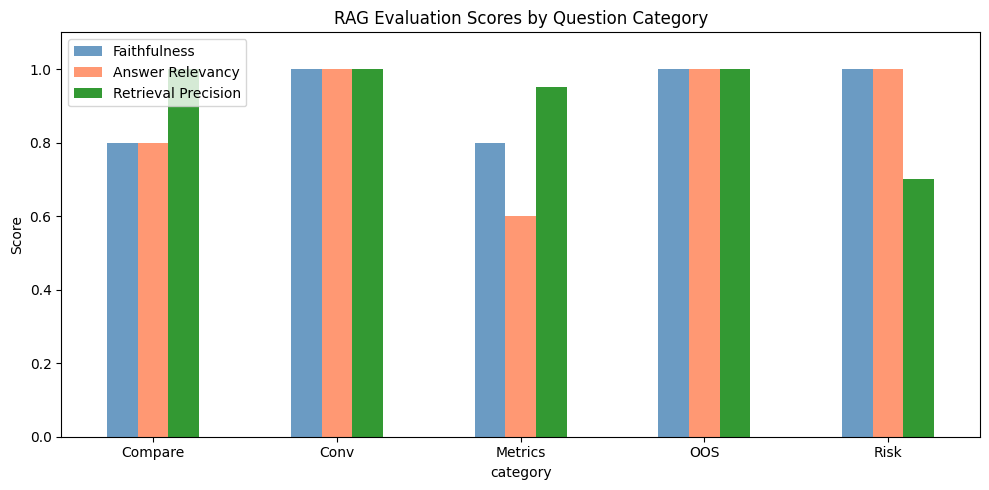

In [7]:
print('=' * 50)
print('   EVALUATION RESULTS SUMMARY')
print('=' * 50)
print(f'Questions evaluated   : {len(df)}')
print(f'Faithfulness score    : {df["faithfulness"].mean():.1%}')
print(f'Answer relevancy score: {df["relevancy"].mean():.1%}')
print(f'Retrieval precision   : {df["precision"].mean():.1%}')
print(f'Average latency       : {df["latency"].mean():.2f}s')
print(f'Average tokens/query  : {df["tokens"].mean():.0f}')
print()

# Visualise scores by category
cat_summary = df.groupby('category')[['faithfulness','relevancy','precision']].mean()

fig, ax = plt.subplots(figsize=(10, 5))
cat_summary.plot(kind='bar', ax=ax, color=['steelblue','coral','green'], alpha=0.8)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('RAG Evaluation Scores by Question Category')
ax.legend(['Faithfulness','Answer Relevancy','Retrieval Precision'])
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 8. Save Results to reports/evaluation_results.md

In [10]:
faith_pct  = df['faithfulness'].mean() * 100
rel_pct    = df['relevancy'].mean() * 100
prec_pct   = df['precision'].mean() * 100
avg_lat    = df['latency'].mean()
avg_tok    = df['tokens'].mean()

report = f"""# RAG Evaluation Results

**System:** Financial RAG Assistant — LangChain + ChromaDB + gpt-4o-mini  
**Test set:** 20 questions across 5 categories  
**Documents:** JPMorgan Chase, Bank of America, Wells Fargo 2023 10-K filings  

## Overall Metrics

| Metric | Score |
|--------|-------|
| **Faithfulness** | {faith_pct:.1f}% |
| **Answer Relevancy** | {rel_pct:.1f}% |
| **Retrieval Precision** | {prec_pct:.1f}% |
| **Average Latency** | {avg_lat:.2f}s |
| **Avg Tokens / Query** | {avg_tok:.0f} |

## Scores by Category

{cat_summary.round(3).to_markdown()}

## Configuration

| Parameter | Value |
|-----------|-------|
| LLM | gpt-4o-mini (temperature=0, max_tokens=500) |
| Embeddings | text-embedding-3-small (1536 dims) |
| Vector store | ChromaDB (local, persisted) |
| Chunk size | 500 words |
| Chunk overlap | 50 words |
| Top-k retrieval | 4 chunks |

## Question Breakdown

{df[['id','category','question','faithfulness','relevancy','precision','latency']].to_markdown(index=False)}

---
*Generated by notebook 04_evaluation.ipynb*
"""

output_path = REPORTS_DIR / 'evaluation_results.md'
output_path.write_text(report, encoding='utf-8')
print(f'Report saved → {output_path}')

Report saved → /Users/nicolaszuleta95/code_nz/financial-rag-assistant/reports/evaluation_results.md
